##Looking into how to preprocess mtg cards

In [1]:
import pandas as pd
import numpy as np

In [12]:
mtg_df = pd.read_csv('cards.csv')
mtg_df.head()

C:\Users\Peter\AppData\Local\Temp\ipykernel_16520\3246418638.py:1: DtypeWarning: Columns (16,19,27,46) have mixed types. Specify dtype option on import or set low_memory=False.
  mtg_df = pd.read_csv('cards.csv')


,artist,artistIds,asciiName,attractionLights,availability,boosterTypes,borderColor,cardParts,colorIdentity,colorIndicator,...,subsets,subtypes,supertypes,text,toughness,type,types,uuid,variations,watermark
0,Slawomir Maniak,d887bc66-2779-416c-a1ff-d8720242063e,NaN,NaN,"arena, mtgo, paper",default,black,NaN,R,NaN,...,NaN,NaN,NaN,Reckless Rage deals 4 damage to target creatur...,NaN,Instant,Instant,18d320b3-3b97-5cfc-959c-66e22911627b,NaN,NaN
1,Jesper Ejsing,a5f8354a-8b51-4e59-96b2-0e3aeae4fa1d,NaN,NaN,paper,NaN,black,NaN,"U, W",NaN,...,NaN,Sphinx,NaN,"Flying, lifelink\nWhenever you draw a card, th...",5,Creature — Sphinx,Creature,e4eb8663-1d62-5abc-bbfe-ff9dd2de43c0,74ac3158-8f5d-5c94-a40a-1a7129b46a5b,NaN
2,Kev Walker,f366a0ee-a0cd-466d-ba6a-90058c7a31a6,NaN,NaN,paper,NaN,black,NaN,W,NaN,...,NaN,NaN,NaN,Destroy target permanent. Its controller creat...,NaN,Instant,Instant,64f3de78-c603-5aa9-bd74-9feafc32f476,NaN,NaN
3,Micah Epstein,957ec398-9a5e-4f54-9090-37a06d57b96c,NaN,NaN,paper,NaN,black,NaN,B,NaN,...,NaN,"Tiefling, Cleric",NaN,Flying\nEach creature card in your graveyard t...,5,Creature — Tiefling Cleric,Creature,eb9438f3-96b5-5fa1-ad63-8905500a9c66,88808ec3-1f06-5552-b891-d828de1078a6,NaN
4,Svetlin Velinov,ffd063ae-c097-4f26-b2e6-b1e2137708bc,NaN,NaN,paper,NaN,black,NaN,B,NaN,...,NaN,Sliver,NaN,"Whenever a Sliver you control attacks, defendi...",1,Creature — Sliver,Creature,38d1f975-1b3b-5047-8328-61f5ca71ddba,NaN,NaN


What columns are we not interested in looking at this we can say. 

To be remove asciiName, cardParts, borderColor, boosterTypes, remove cards from online versions of magic that would clash, finishes

kept isTextless as it might be important to sift through

In [13]:
mtg_df = mtg_df.drop(columns=['asciiName','attractionLights','cardParts', 'boosterTypes','borderColor','availability','facePrintedName','finishes','frameEffects','isReprint'
                              ,'isReserved','isStorySpotlight','isTimeshifted','hasContentWarning','isAlternative','isFullArt','isFunny','isOversized','isPromo','isRebalanced'
                              ,'language','leadershipSkills','life','loyalty','originalPrintings','originalReleaseDate','originalText','otherFaceIds','printedName'
                              ,'printedText','printedType','promoTypes','rebalancedPrintings','relatedCards','securityStamp','side','signature'
                              ,'sourceProducts','subsets','subtypes','supertypes','types','variations','watermark', 'hasAlternativeDeckLimit','hasContentWarning'
                              ,'isAlternative','isFullArt','isFunny','hand','defense','duelDeck','isOversized','isPromo','isRebalanced'])

In [14]:
mtg_df.to_csv('littleClean_mtg_cards.csv')

In [15]:
mtg_df2 = pd.read_csv('littleClean_mtg_cards.csv')

In [16]:
NER_DF = mtg_df2[['frameVersion','setCode','isOnlineOnly','isTextless','keywords','name','text','uuid','type']]

In [17]:
NER_DF.set_index('uuid', inplace=True)


In [18]:
NER_DF.to_csv('NER_DF.csv')

PermissionError: [Errno 13] Permission denied: 'NER_DF.csv'

In [19]:
NER_DF

,frameVersion,setCode,isOnlineOnly,isTextless,keywords,name,text,type
uuid,,,,,,,,
18d320b3-3b97-5cfc-959c-66e22911627b,2015,RIX,False,False,NaN,Reckless Rage,Reckless Rage deals 4 damage to target creatur...,Instant
e4eb8663-1d62-5abc-bbfe-ff9dd2de43c0,2015,PTHB,False,False,"Flying, Lifelink",Dream Trawler,"Flying, lifelink\nWhenever you draw a card, th...",Creature — Sphinx
64f3de78-c603-5aa9-bd74-9feafc32f476,2015,NCC,False,False,NaN,Generous Gift,Destroy target permanent. Its controller creat...,Instant
eb9438f3-96b5-5fa1-ad63-8905500a9c66,2015,CLB,False,False,Flying,Solemn Doomguide,Flying\nEach creature card in your graveyard t...,Creature — Tiefling Cleric
38d1f975-1b3b-5047-8328-61f5ca71ddba,2015,SLD,False,False,NaN,Leeching Sliver,"Whenever a Sliver you control attacks, defendi...",Creature — Sliver
...,...,...,...,...,...,...,...,...
99da7b6c-c109-5b86-b521-c8cd3a5863d2,2015,DRC,False,False,NaN,Retrofitter Foundry,"{3}: Untap this artifact.\n{2}, {T}: Create a ...",Artifact
6342aab5-213b-5d84-9923-2fb70968abc3,2015,WHO,False,False,"Vigilance, Suspend, Trample",Dinosaurs on a Spaceship,"Vigilance, trample\nOther Dinosaurs you contro...",Creature — Dinosaur
0a2ad29a-7d44-5974-b553-8dc5e09c6312,2015,INR,False,False,Defender,Thermo-Alchemist,Defender\n{T}: This creature deals 1 damage to...,Creature — Human Shaman


In [20]:
NER_DF.count()

frameVersion    109018
setCode         109018
isOnlineOnly    109018
isTextless      109018
keywords         46948
name            109018
text            107878
type            109018
dtype: int64

In [21]:
len(NER_DF['name'].unique())

33611

In [22]:
NER_DF['name'].unique()

array(['Reckless Rage', 'Dream Trawler', 'Generous Gift', ...,
       'Platypus-Bear', 'Viashino Outrider', 'Nimbus Wings'],
      shape=(33611,), dtype=object)

In [23]:
editedDF = NER_DF.drop_duplicates('name')

In [24]:
editedDF = editedDF.drop_duplicates('text')

In [51]:
editedDF.to_csv('mtg_processed.csv')

##Visualisation##

C:\Users\Peter\AppData\Local\Temp\ipykernel_44420\1863381770.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


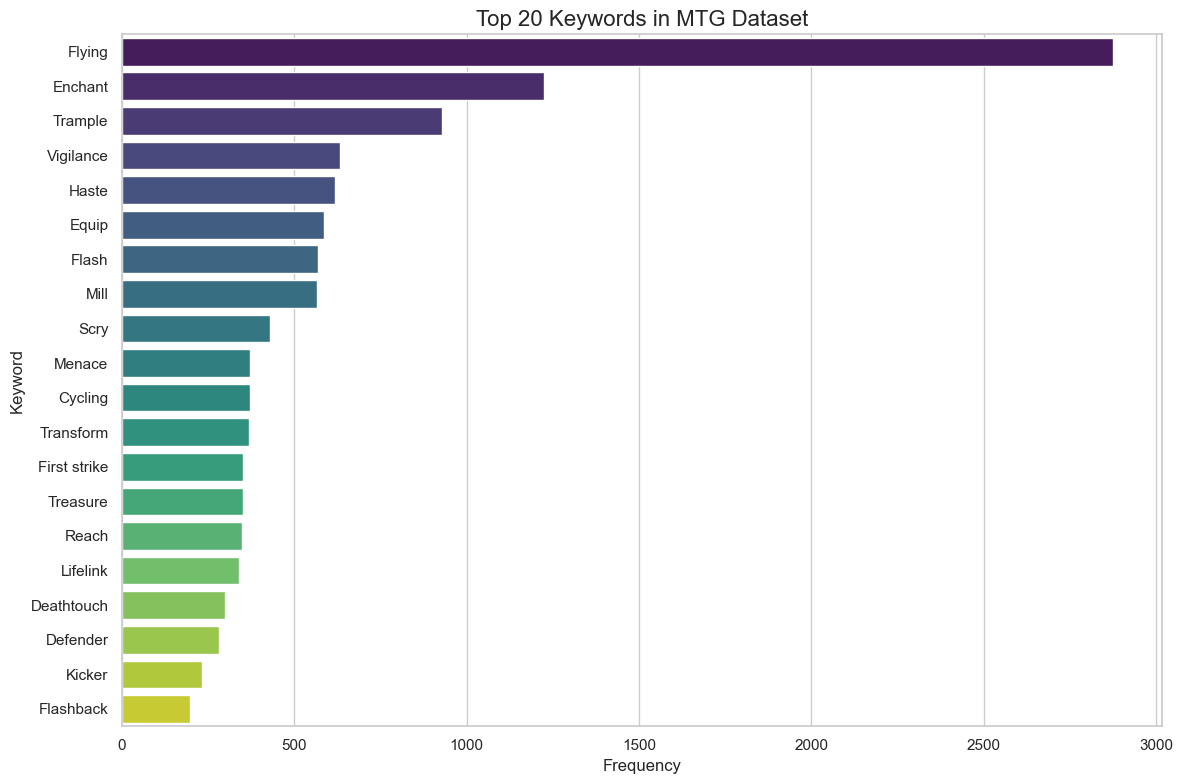

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('mtg_processed.csv')

# Preprocessing: Handle nulls and split comma-separated keywords
# We drop rows with no keywords and explode the comma-separated strings into individual rows
df_keywords = df.dropna(subset=['keywords']).copy()
df_keywords['keyword_list'] = df_keywords['keywords'].str.split(',')
exploded_df = df_keywords.explode('keyword_list')

# Clean whitespace from the keyword strings
exploded_df['keyword_list'] = exploded_df['keyword_list'].str.strip()

# Calculate the frequency of each keyword
keyword_counts = exploded_df['keyword_list'].value_counts().reset_index()
keyword_counts.columns = ['Keyword', 'Count']

# Visualization using Seaborn and Matplotlib
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Plot the top 20 keywords for readability
sns.barplot(
    data=keyword_counts.head(20), 
    x='Count', 
    y='Keyword', 
    palette='viridis'
)

plt.title('Top 20 Keywords in MTG Dataset', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Keyword', fontsize=12)
plt.tight_layout()

# Save or show the plot
plt.savefig('keyword_distribution.png')
plt.show()

In [ ]:
# Load the dataset
df = pd.read_csv('mtg_processed.csv')

# Drop rows where keywords are missing
df_keywords = df.dropna(subset=['keywords']).copy()

# Split the comma-separated keywords into lists
df_keywords['keyword_list'] = df_keywords['keywords'].str.split(',')

# Explode the lists into individual rows so each keyword has its own entry
exploded_df = df_keywords.explode('keyword_list')

# Clean leading and trailing whitespace from each keyword string
exploded_df['keyword_list'] = exploded_df['keyword_list'].str.strip()

# Count the occurrences of each unique keyword
keyword_frequencies = exploded_df['keyword_list'].value_counts().reset_index()
keyword_frequencies.columns = ['Keyword', 'Frequency']

# Save the resulting frequency table to a new CSV file
keyword_frequencies.to_csv('keyword_frequencies.csv', index=False)

# Display the first few rows of the generated table
print(keyword_frequencies.head())

     Keyword  Frequency
0     Flying       2874
1    Enchant       1224
2    Trample        930
3  Vigilance        634
4      Haste        618


In [30]:
df.head()

,uuid,frameVersion,setCode,isOnlineOnly,isTextless,keywords,name,text,type
0,18d320b3-3b97-5cfc-959c-66e22911627b,2015,RIX,False,False,NaN,Reckless Rage,Reckless Rage deals 4 damage to target creatur...,Instant
1,e4eb8663-1d62-5abc-bbfe-ff9dd2de43c0,2015,PTHB,False,False,"Flying, Lifelink",Dream Trawler,"Flying, lifelink\nWhenever you draw a card, th...",Creature — Sphinx
2,64f3de78-c603-5aa9-bd74-9feafc32f476,2015,NCC,False,False,NaN,Generous Gift,Destroy target permanent. Its controller creat...,Instant
3,eb9438f3-96b5-5fa1-ad63-8905500a9c66,2015,CLB,False,False,Flying,Solemn Doomguide,Flying\nEach creature card in your graveyard t...,Creature — Tiefling Cleric
4,38d1f975-1b3b-5047-8328-61f5ca71ddba,2015,SLD,False,False,NaN,Leeching Sliver,"Whenever a Sliver you control attacks, defendi...",Creature — Sliver


In [31]:
name_df = df.drop(columns=['frameVersion','setCode','isOnlineOnly','isTextless','keywords','type'])

In [33]:
name_df = name_df.drop(columns=['text'])

In [34]:
name_df

,uuid,name
0,18d320b3-3b97-5cfc-959c-66e22911627b,Reckless Rage
1,e4eb8663-1d62-5abc-bbfe-ff9dd2de43c0,Dream Trawler
2,64f3de78-c603-5aa9-bd74-9feafc32f476,Generous Gift
3,eb9438f3-96b5-5fa1-ad63-8905500a9c66,Solemn Doomguide
4,38d1f975-1b3b-5047-8328-61f5ca71ddba,Leeching Sliver
...,...,...
31112,6fb939cc-6091-5399-9106-fa863d212cb9,Journey of Discovery
31113,30306284-3c15-5313-beef-84f0fd3e360c,A-Harald Unites the Elves
31114,76d70ede-6a05-580a-9f12-5aec082b5fab,Platypus-Bear
31115,90d22cd6-fea2-537b-97aa-1e696d0bbf32,Viashino Outrider


In [25]:
len(name_df['uuid'].unique())

31117

In [2]:
rulesDF = pd.read_csv('cardRulings.csv')

In [3]:
len(rulesDF)

258813

In [4]:
rulesDF.head()

,uuid,date,rules
0,18d320b3-3b97-5cfc-959c-66e22911627b,19/01/2018,You can’t cast Reckless Rage unless you choose...
1,18d320b3-3b97-5cfc-959c-66e22911627b,19/01/2018,If either target is an illegal target as Reckl...
2,e4eb8663-1d62-5abc-bbfe-ff9dd2de43c0,24/01/2020,You can activate Dream Trawler's last ability ...
3,e4eb8663-1d62-5abc-bbfe-ff9dd2de43c0,24/01/2020,Dream Trawler's second triggered ability resol...
4,64f3de78-c603-5aa9-bd74-9feafc32f476,14/06/2019,If the target permanent is an illegal target b...


In [5]:
rulesDF = rulesDF.drop_duplicates('rules')

In [6]:
rulesDF = rulesDF.drop(columns=['date'])

In [7]:
len(rulesDF)

33365

In [8]:
rulesDF

,uuid,rules
0,18d320b3-3b97-5cfc-959c-66e22911627b,You can’t cast Reckless Rage unless you choose...
1,18d320b3-3b97-5cfc-959c-66e22911627b,If either target is an illegal target as Reckl...
2,e4eb8663-1d62-5abc-bbfe-ff9dd2de43c0,You can activate Dream Trawler's last ability ...
3,e4eb8663-1d62-5abc-bbfe-ff9dd2de43c0,Dream Trawler's second triggered ability resol...
4,64f3de78-c603-5aa9-bd74-9feafc32f476,If the target permanent is an illegal target b...
...,...,...
258606,233784b1-3db1-5ed6-9262-04c55217c7d9,"The ability has you draw one or two cards, but..."
258612,f811931c-810f-58cd-86e4-50be261ec920,You could target a creature you control with S...
258613,f811931c-810f-58cd-86e4-50be261ec920,Smoke Teller’s ability lets you look at the cr...
258785,6fb939cc-6091-5399-9106-fa863d212cb9,If you cast an entwined Journey of Discovery u...


In [9]:
rulesDF = rulesDF.groupby(['uuid'])['rules'].sum().reset_index()

In [10]:
len(rulesDF)

14571

In [11]:
rulesDF.to_csv('rules_DF.csv')